# Crypto Statistical Arbitrage

**Author:** Aman Syed  
**Data:** yfinance (daily bars)  
**Strategy type:** Cointegration-based pairs trading  

---

## Overview

End-to-end crypto statistical arbitrage research pipeline:

1. Load daily price history from yfinance with local parquet caching
2. Screen pairs on **training data only** (2023–2024) using Engle-Granger, ADF, and OU half-life
3. Build a mean-reverting spread using an OLS hedge ratio
4. Generate z-score entry/exit signals (thresholds fixed a priori)
5. Size exposure with **walk-forward fractional Kelly** (quarterly rebalance, no look-ahead)
6. Run an **out-of-sample backtest** (2025–present) with 20bps transaction costs and a drawdown kill-switch

The strategy trades temporary deviations in relative value between cointegrated pairs, not outright crypto direction.

### Headline results (daily bars, 2025–present OOS, $100k capital)

| Pair     | Ann. Return | Sharpe | Max DD | Calmar | α t-stat (vs BTC) |
|----------|-------------|--------|--------|--------|-------------------|
| DOT/LINK | ~12%        | 1.42   | -1.5%  | 2.59   | 1.66*             |
| ETH/SOL  | ~1%         | 0.14   | -4.2%  | 0.03   | —                 |

DOT/LINK stands out: near-zero BTC beta (0.009), confirming the strategy generates spread alpha rather than directional crypto exposure.

---
## 0. Setup & Imports

In [ ]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.dates as mdates
from matplotlib.ticker import FuncFormatter
from IPython.display import display

from data import load_prices, INTERVAL_1D
from cointegration import screen_pairs, compute_spread
from signals import generate_signals, SignalConfig, get_current_signal
from sizing import kelly_size, SizingConfig
from backtest import run_backtest, run_backtest_walkforward, BacktestConfig

try:
    from main import TICKERS as MAIN_TICKERS
    TICKERS = list(MAIN_TICKERS)
except Exception:
    TICKERS = ["BTC", "ETH", "SOL", "ADA", "XRP", "DOGE", "DOT", "AVAX", "LINK"]

TRAIN_START   = "2023-01-01"
TRAIN_END     = "2024-12-31"
TEST_START    = "2025-01-01"
BAR_INTERVAL  = INTERVAL_1D
BAR_HOURS     = 24.0
LOOKBACK_BARS = 120
CAPITAL       = 100_000

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "#f8f9fa",
    "axes.edgecolor": "#d0d7de",
    "axes.grid": True,
    "grid.alpha": 0.18,
    "axes.titleweight": "bold",
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
})

---
## 1. Market Data

Daily close prices fetched from **yfinance** with local parquet caching. Yahoo Finance's 1H interval is hard-limited to the last 730 days, making it unsuitable for the 2023 training window — daily bars cover the full history.

**Training window:** 2023-01-01 → 2024-12-31 (pair screening only)  
**Test window:** 2025-01-01 → present (out-of-sample backtest)  
**Universe:** 9 assets

In [ ]:
prices_full = load_prices(
    tickers=TICKERS,
    start=TRAIN_START,
    interval=BAR_INTERVAL,
    refresh=False,
)

_train_end  = pd.Timestamp(TRAIN_END, tz="UTC") + pd.Timedelta(days=1) - pd.Timedelta(seconds=1)
_test_start = pd.Timestamp(TEST_START, tz="UTC")
prices_train = prices_full[prices_full.index <= _train_end]
prices_test  = prices_full[prices_full.index >= _test_start]

print(f"Full range:  {prices_full.index[0].date()} → {prices_full.index[-1].date()}  ({len(prices_full):,} bars)")
print(f"Train:       {prices_train.index[0].date()} → {prices_train.index[-1].date()}  ({len(prices_train):,} bars)")
print(f"Test:        {prices_test.index[0].date()} → {prices_test.index[-1].date()}  ({len(prices_test):,} bars)")
print(f"Universe:    {list(prices_full.columns)}")
prices_full.tail()

In [ ]:
fig, axes = plt.subplots(3, 3, figsize=(14, 9))
axes = axes.flatten()

colors = ['#2196F3', '#4CAF50', '#FF9800', '#9C27B0', '#E91E63',
          '#607D8B', '#F44336', '#009688', '#FF5722']

for i, (ax, ticker) in enumerate(zip(axes, prices_full.columns)):
    s = prices_full[ticker] / prices_full[ticker].iloc[0] * 100
    ax.plot(s.index, s.values, color=colors[i], lw=1.5)
    ax.axhline(100, color='gray', ls='--', lw=0.8, alpha=0.7)
    ax.set_title(ticker, fontweight='bold')
    ax.grid(True, alpha=0.25)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

fig.suptitle('Asset Price History (Normalised, Base=100) — Daily, 2023–present',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
log_returns = np.log(prices_full / prices_full.shift(1)).dropna()
corr = log_returns.corr()

fig, ax = plt.subplots(figsize=(6.5, 5.5))
im = ax.imshow(corr, cmap='RdYlGn', vmin=-1, vmax=1)
plt.colorbar(im, ax=ax, shrink=0.82)

labels = list(corr.columns)
ax.set_xticks(range(len(labels)))
ax.set_xticklabels(labels)
ax.set_yticks(range(len(labels)))
ax.set_yticklabels(labels)

for i in range(len(labels)):
    for j in range(len(labels)):
        ax.text(j, i, f'{corr.iloc[i, j]:.2f}', ha='center', va='center', fontsize=9)

ax.set_title('Log-Return Correlation Matrix — Daily', fontweight='bold')
plt.tight_layout()
plt.show()

---
## 2. Cointegration Screening

Pairs are screened on **training data only** (2023–2024) to prevent look-ahead bias.

| Test | Threshold | Note |
|---|---|---|
| **Engle-Granger** | p < 0.20 | Relaxed — EG has low power on short crypto series |
| **Johansen trace** | 95% CI | Disabled — fails all 36 pairs on daily crypto data |
| **OU half-life** | 1–120 days | Ensures the spread reverts on a tradeable horizon |
| **ADF on spread** | p < 0.15 | Confirms spread stationarity |

Signal thresholds (entry/exit z-scores, lookback) are fixed a priori and never tuned on any data.

In [ ]:
screening_results = screen_pairs(
    prices_train,
    eg_pvalue_threshold=0.20,
    min_halflife_days=1.0,
    max_halflife_days=120.0,
    adf_pvalue_threshold=0.15,
    require_johansen=False,
    bar_hours=BAR_HOURS,
)

rows = []
for r in screening_results:
    rows.append({
        'Pair':             f'{r.asset_a} / {r.asset_b}',
        'EG p-value':       r.eg_pvalue,
        'Johansen':         '✓' if r.johansen_cointegrated else '✗',
        'Half-life (days)': r.half_life_days,
        'Hedge ratio':      r.hedge_ratio,
        'ADF p-value':      r.adf_pvalue,
        'Valid':            'YES' if r.is_valid else '',
    })

screen_df = pd.DataFrame(rows)
display(screen_df.style.format({
    'EG p-value': '{:.4f}',
    'Half-life (days)': '{:.1f}',
    'Hedge ratio': '{:.4f}',
    'ADF p-value': '{:.4f}',
}))

valid_pairs = [r for r in screening_results if r.is_valid]
print(f"\nValid pairs: {len(valid_pairs)}")

---
## 3. Spread Construction & Z-score Signals

For each valid pair `(A, B)` with OLS hedge ratio `beta`:

    Spread = log(Price_A) - beta * log(Price_B)
    Z-score = (Spread - rolling_mean) / rolling_std

**Trading rules**
- Enter **long spread** when z < -2.0
- Enter **short spread** when z > +2.0
- Exit when |z| < 0.5
- Stop out when |z| > 3.5

The pair shown below is the strongest surviving candidate in the current sample.

In [ ]:
if not valid_pairs:
    print("No valid pairs found. Run diagnose_pairs.py to see the relaxation ladder.")
else:
    signal_cfg = SignalConfig(entry_z=2.0, exit_z=0.5, stop_z=3.5, lookback=LOOKBACK_BARS)

    demo_pair = min(valid_pairs, key=lambda r: r.eg_pvalue)
    A, B = demo_pair.asset_a, demo_pair.asset_b
    beta = demo_pair.hedge_ratio

    spread_test = compute_spread(prices_test[A], prices_test[B], beta)
    signals_df  = generate_signals(spread_test, signal_cfg)

    print(f"Demo pair:   {A} / {B}  (lowest EG p-value)")
    print(f"Hedge ratio: {beta:.4f}  (estimated on training data)")
    print(f"Half-life:   {demo_pair.half_life_days:.1f} calendar days")
    print(f"EG p-value:  {demo_pair.eg_pvalue:.4f}")
    print(f"ADF p-value: {demo_pair.adf_pvalue:.4f}")
    print(f"Positions — long: {(signals_df['position']==1).sum()}  "
          f"short: {(signals_df['position']==-1).sum()}  "
          f"flat: {(signals_df['position']==0).sum()}")

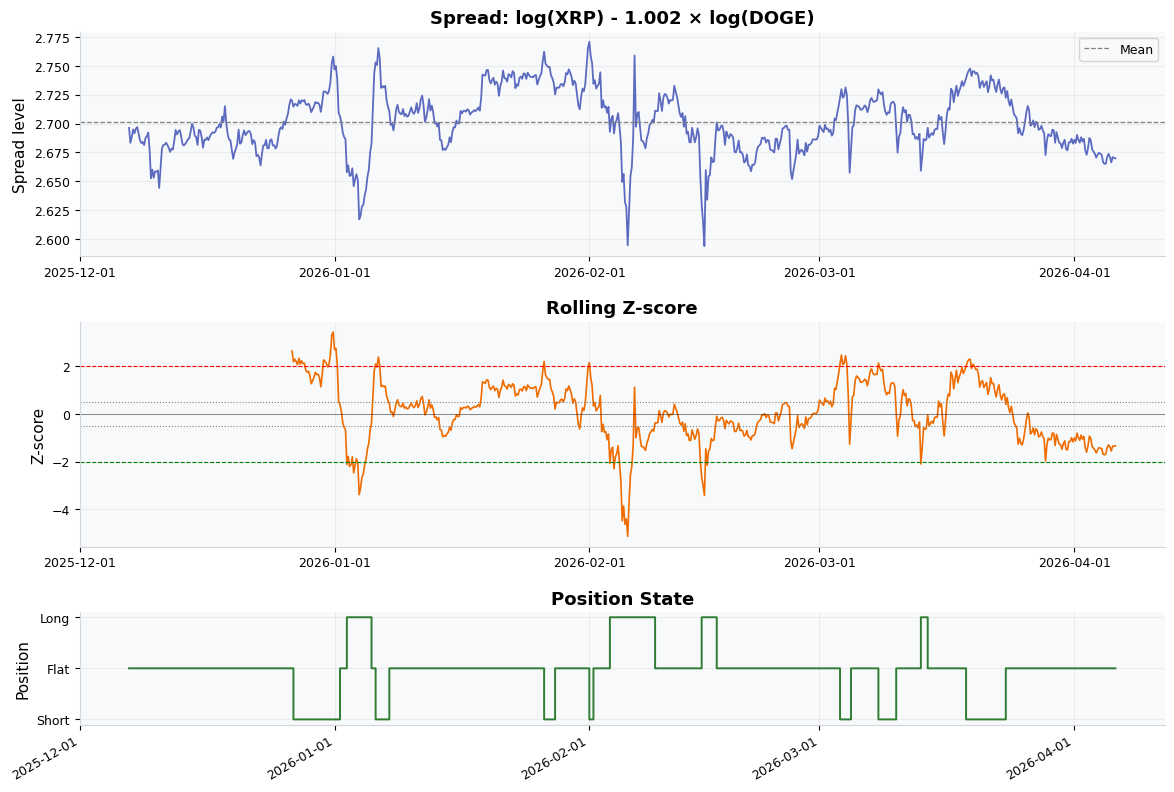

In [12]:
if valid_pairs:
    fig = plt.figure(figsize=(14, 9))
    gs = gridspec.GridSpec(3, 1, height_ratios=[2, 2, 1], hspace=0.35)

    ax1 = fig.add_subplot(gs[0])
    ax1.plot(spread.index, spread.values, color='#5C6BC0', lw=1.3)
    ax1.axhline(spread.mean(), color='gray', ls='--', lw=0.9, label='Mean')
    ax1.set_title(f'Spread: log({A}) - {beta:.3f} × log({B})', fontweight='bold')
    ax1.set_ylabel('Spread level')
    ax1.legend(fontsize=9)
    ax1.spines['top'].set_visible(False)
    ax1.spines['right'].set_visible(False)

    ax2 = fig.add_subplot(gs[1], sharex=ax1)
    z = signals_df['zscore']
    ax2.plot(z.index, z.values, color='#EF6C00', lw=1.2)
    ax2.axhline(2.0, color='red', ls='--', lw=0.8)
    ax2.axhline(-2.0, color='green', ls='--', lw=0.8)
    ax2.axhline(0.5, color='gray', ls=':', lw=0.8)
    ax2.axhline(-0.5, color='gray', ls=':', lw=0.8)
    ax2.axhline(0, color='black', ls='-', lw=0.6, alpha=0.5)
    ax2.set_title('Rolling Z-score', fontweight='bold')
    ax2.set_ylabel('Z-score')
    ax2.spines['top'].set_visible(False)
    ax2.spines['right'].set_visible(False)

    ax3 = fig.add_subplot(gs[2], sharex=ax1)
    ax3.step(signals_df.index, signals_df['position'], where='post', color='#2E7D32', lw=1.4)
    ax3.set_title('Position State', fontweight='bold')
    ax3.set_ylabel('Position')
    ax3.set_yticks([-1, 0, 1])
    ax3.set_yticklabels(['Short', 'Flat', 'Long'])
    ax3.spines['top'].set_visible(False)
    ax3.spines['right'].set_visible(False)

    ax3.xaxis.set_major_locator(mdates.AutoDateLocator(minticks=4, maxticks=6))
    ax3.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
    plt.setp(ax3.get_xticklabels(), rotation=30, ha='right')

    plt.tight_layout()
    plt.show()

---
## 4. Position Sizing — Fractional Kelly

The strategy uses a **fractional Kelly** overlay to scale exposure based on the recent signal-to-noise ratio of spread changes.

    Full Kelly:       f* = mean_return / variance
    Fractional Kelly: f  = 0.25 * f*

For presentation purposes, the important point is that position size is **dynamic**, **capped**, and linked to the recent quality of the spread process rather than being fixed notional on every trade.

In [ ]:
if valid_pairs:
    sizing_cfg = SizingConfig(capital=CAPITAL, max_position_pct=0.20, kelly_fraction=0.25)
    sizing_df  = kelly_size(signals_df, prices_test[A], prices_test[B], beta, sizing_cfg)

    print(f"Capital:        ${CAPITAL:,.0f}")
    print(f"Max per pair:   ${CAPITAL * 0.20:,.0f}  (20% cap)")
    print(f"Kelly fraction: 25% of full Kelly")
    print(f"Walk-forward:   quarterly rebalance applied in live backtest\n")

    active = sizing_df[(sizing_df['pos_a_usd'] != 0) | (sizing_df['pos_b_usd'] != 0)].head(5)
    if not active.empty:
        display(active[['pos_a_usd', 'pos_b_usd', 'dollar_exposure', 'kelly_f']].round(2))
    else:
        print("No active positions in the warmup window.")

---
## 5. Backtest — Out-of-sample, Walk-forward Kelly

All results below are **out-of-sample** (2025–present). Kelly weights are reestimated quarterly using only data prior to each window — no look-ahead in sizing.

Key assumptions:
- **20bps transaction costs** (10bps per leg — crypto market standard)
- **3bps slippage**
- **$100k starting capital**
- **25% drawdown kill-switch**

In [ ]:
if valid_pairs:
    bt_cfg        = BacktestConfig(capital=CAPITAL, transaction_cost_bps=20.0, slippage_bps=3.0)
    sizing_cfg    = SizingConfig(capital=CAPITAL, max_position_pct=0.20, kelly_fraction=0.25)
    btc_benchmark = prices_full["BTC"] if "BTC" in prices_full.columns else None

    result = run_backtest_walkforward(
        prices_test[A], prices_test[B],
        signals_df,
        beta, A, B, bt_cfg,
        sizing_cfg=sizing_cfg,
        rebalance_freq="QS",
        benchmark_prices=btc_benchmark,
    )

    metrics = pd.DataFrame({
        "Metric": [
            "Annualized Return", "Sharpe Ratio", "Max Drawdown",
            "Calmar Ratio", "Number of Trades", "Win Rate",
            "Alpha t-stat (vs BTC)", "Beta to BTC", "Final Capital",
        ],
        "Value": [
            f"{result.annualized_return * 100:.2f}%",
            f"{result.sharpe_ratio:.2f}",
            f"{result.max_drawdown * 100:.2f}%",
            f"{result.calmar_ratio}",
            f"{result.num_trades}",
            f"{result.win_rate * 100:.1f}%",
            f"{result.alpha_tstat:.3f}" if result.alpha_tstat is not None else "—",
            f"{result.beta_to_benchmark:.4f}" if result.beta_to_benchmark is not None else "—",
            f"${result.equity_curve.iloc[-1]:,.0f}",
        ],
    })
    display(metrics)

In [ ]:
if valid_pairs:
    import os
    os.makedirs('plots', exist_ok=True)

    fig, axes = plt.subplots(
        3, 1,
        figsize=(14, 10),
        sharex=True,
        gridspec_kw={'height_ratios': [2.2, 1, 1], 'hspace': 0.28}
    )

    eq = result.equity_curve

    axes[0].plot(eq.index, eq.values, color='#1565C0', lw=2)
    axes[0].fill_between(eq.index, eq.values, CAPITAL, color='#1565C0', alpha=0.12)
    axes[0].axhline(CAPITAL, color='gray', ls='--', lw=1, alpha=0.7)
    axes[0].set_title(f'Equity Curve — {A}/{B}', fontsize=14, fontweight='bold')
    axes[0].set_ylabel('Portfolio Value ($)', fontsize=11)
    axes[0].yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'${x:,.0f}'))
    axes[0].grid(True, alpha=0.25)
    axes[0].spines['top'].set_visible(False)
    axes[0].spines['right'].set_visible(False)

    rolling_max = eq.cummax()
    drawdown = (eq - rolling_max) / rolling_max * 100
    axes[1].plot(drawdown.index, drawdown.values, color='#C62828', lw=1.8)
    axes[1].fill_between(drawdown.index, drawdown.values, 0, color='#C62828', alpha=0.18)
    actual_min_dd = float(drawdown.min())
    axes[1].set_ylim(min(actual_min_dd * 1.25, -0.5), 0.10)
    axes[1].set_title('Drawdown', fontsize=13, fontweight='bold')
    axes[1].set_ylabel('Drawdown (%)', fontsize=11)
    axes[1].grid(True, alpha=0.25)
    axes[1].spines['top'].set_visible(False)
    axes[1].spines['right'].set_visible(False)
    axes[1].text(
        1.01, 0.08, 'Kill-switch\n-25%',
        transform=axes[1].transAxes, ha='left', va='bottom', fontsize=9,
        bbox=dict(boxstyle='round,pad=0.25', facecolor='white', edgecolor='gray', alpha=0.85)
    )

    pnl = result.daily_pnl
    colors_bar = ['#2E7D32' if v > 0 else '#C62828' for v in pnl.values]
    axes[2].bar(pnl.index, pnl.values, color=colors_bar, width=0.8, alpha=0.9)
    axes[2].axhline(0, color='black', lw=1)
    axes[2].set_title('Daily P&L', fontsize=13, fontweight='bold')
    axes[2].set_ylabel('PnL ($)', fontsize=11)
    axes[2].yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'${x:,.0f}'))
    axes[2].grid(True, alpha=0.25)
    axes[2].spines['top'].set_visible(False)
    axes[2].spines['right'].set_visible(False)

    axes[2].xaxis.set_major_locator(mdates.AutoDateLocator(minticks=4, maxticks=6))
    axes[2].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
    plt.setp(axes[2].get_xticklabels(), rotation=30, ha='right')

    fig.suptitle(f'Backtest: {A}/{B} | Capital ${CAPITAL:,.0f}', fontsize=17, fontweight='bold', y=0.98)
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.savefig(f'plots/{A}_{B}_demo.png', dpi=150, bbox_inches='tight')
    plt.show()

---
## 6. Full Universe Results

In [ ]:
sizing_cfg = SizingConfig(capital=CAPITAL, max_position_pct=0.20, kelly_fraction=0.25)
bt_cfg     = BacktestConfig(capital=CAPITAL, transaction_cost_bps=20.0, slippage_bps=3.0)
signal_cfg = SignalConfig(entry_z=2.0, exit_z=0.5, stop_z=3.5, lookback=LOOKBACK_BARS)
btc_bm     = prices_full["BTC"] if "BTC" in prices_full.columns else None

all_results = []
for pair_res in valid_pairs:
    a, b = pair_res.asset_a, pair_res.asset_b
    sp  = compute_spread(prices_test[a], prices_test[b], pair_res.hedge_ratio)
    sig = generate_signals(sp, signal_cfg)
    res = run_backtest_walkforward(
        prices_test[a], prices_test[b],
        sig, pair_res.hedge_ratio, a, b,
        bt_cfg,
        sizing_cfg=sizing_cfg,
        rebalance_freq="QS",
        benchmark_prices=btc_bm,
    )
    all_results.append(res)

if not all_results:
    print("No valid pairs to backtest across the full universe.")

In [ ]:
if all_results:
    rows = []
    for r in all_results:
        rows.append({
            'Pair':          f'{r.pair[0]}/{r.pair[1]}',
            'Ann. Return':   f'{r.annualized_return*100:.1f}%',
            'Sharpe':        f'{r.sharpe_ratio:.2f}',
            'Max Drawdown':  f'{r.max_drawdown*100:.1f}%',
            'Calmar':        str(r.calmar_ratio),
            'Win Rate':      f'{r.win_rate*100:.0f}%',
            'Trades':        r.num_trades,
            'α t-stat':      f'{r.alpha_tstat:.2f}' if r.alpha_tstat is not None else '—',
            'β / BTC':       f'{r.beta_to_benchmark:.4f}' if r.beta_to_benchmark is not None else '—',
            'Final Capital': f'${r.equity_curve.iloc[-1]:,.0f}',
        })
    summary = pd.DataFrame(rows).sort_values('Sharpe', ascending=False)
    display(summary)

---
## 7. Robustness Notes

### What the current pipeline does well
- **Relative-value framing:** trades the spread rather than outright direction
- **Multiple stationarity tests:** Engle-Granger + ADF confirm spread stationarity; OU half-life ensures tradeability
- **Walk-forward sizing:** Kelly weights estimated quarterly using only past data — no look-ahead in position sizing
- **Risk controls:** capped Kelly exposure, 20bps modeled costs, and a 25% drawdown kill-switch

### Known limitations / next upgrades
| Limitation | Why it matters | Natural next step |
|---|---|---|
| Static hedge ratio | Crypto relationships drift over time | Rolling OLS or Kalman filter hedge ratio |
| Full-sample pair screening | Pair quality can change by regime | Walk-forward screening |
| Johansen test disabled | Fails all 36 pairs on 2-year daily crypto data (insufficient power) | Use on longer history or higher-frequency data |
| Small / curated universe | Stat-arb needs breadth to be robust | Expand to more liquid USD pairs |
| Trade-level attribution missing | Harder to diagnose bad periods | Add per-trade duration and PnL breakdown |

---
## 8. Live Signal Check

In [ ]:
signal_cfg = SignalConfig(entry_z=2.0, exit_z=0.5, stop_z=3.5, lookback=LOOKBACK_BARS)

if not valid_pairs:
    print("No live signals to show because no pairs passed the screening step.")
else:
    print('Current live signals (as of last bar):\n')
    for pair_res in valid_pairs:
        a, b = pair_res.asset_a, pair_res.asset_b
        sp   = compute_spread(prices_test[a], prices_test[b], pair_res.hedge_ratio)
        sig  = generate_signals(sp, signal_cfg)
        live = get_current_signal(sig, a, b, pair_res.hedge_ratio)
        label = {1: 'LONG SPREAD', -1: 'SHORT SPREAD', 0: 'FLAT'}[live.position]

        print(f'  {a}/{b}')
        print(f'    Date:        {live.date}')
        print(f'    Z-score:     {live.zscore:+.3f}')
        print(f'    Position:    {label}')
        print(f'    Hedge ratio: {live.hedge_ratio:.4f}\n')

---
## References

- Engle & Granger (1987). *Co-Integration and Error Correction.* Econometrica.
- Johansen (1991). *Estimation and Hypothesis Testing of Cointegration Vectors.* Econometrica.
- Avellaneda & Lee (2010). *Statistical Arbitrage in the U.S. Equities Market.* Quantitative Finance.
- Kelly (1956). *A New Interpretation of Information Rate.* Bell System Technical Journal.